1. Import Library

In [805]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, cross_validate, KFold, learning_curve, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

2. Inspeksi Awal

In [806]:
df = pd.read_csv("../data/clean_df.csv")

In [807]:
df.shape

(32536, 12)

In [808]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32536 entries, 0 to 32535
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    32536 non-null  int64  
 1   Price         32536 non-null  float64
 2   Location      32536 non-null  object 
 3   Bedroom       32536 non-null  int64  
 4   Bathroom      32536 non-null  int64  
 5   Carport       32536 non-null  int64  
 6   Land          32536 non-null  int64  
 7   Building      32536 non-null  int64  
 8   Month         32536 non-null  int64  
 9   City/Regency  32536 non-null  object 
 10  Latitude      32536 non-null  float64
 11  Longitude     32536 non-null  float64
dtypes: float64(3), int64(7), object(2)
memory usage: 3.0+ MB


In [809]:
df.head()

,Unnamed: 0,Price,Location,Bedroom,Bathroom,Carport,Land,Building,Month,City/Regency,Latitude,Longitude
0,0,"1,600,000,000",Padalarang,2,1,1,72,50,8,West Bandung Regency,-7,107
1,1,"850,000,000",Parongpong,2,1,1,70,80,8,West Bandung Regency,-7,108
2,2,"875,000,000",Buah Batu,3,2,1,60,70,8,Bandung City,-7,108
3,3,"1,750,000,000",Bojongsoang,2,3,1,90,94,8,Bandung Regency,-7,108
4,4,"4,900,000,000",Bojongloa Kidul,4,4,0,200,300,8,Bandung City,-7,108


In [810]:
df.isnull().sum()

Unnamed: 0      0
Price           0
Location        0
Bedroom         0
Bathroom        0
Carport         0
Land            0
Building        0
Month           0
City/Regency    0
Latitude        0
Longitude       0
dtype: int64

In [811]:
print(df.duplicated().sum())

0


In [812]:
df.nunique()

Unnamed: 0      32536
Price             844
Location           66
Bedroom             8
Bathroom            7
Carport             4
Land              520
Building          416
Month               3
City/Regency        3
Latitude           66
Longitude          66
dtype: int64

city = one hot, location = target encoding (diisi rata-rata harga rumah daerah tsb)

In [813]:
df = df.drop(columns=['Unnamed: 0','Latitude', 'Longitude'])

In [814]:
df.head()

,Price,Location,Bedroom,Bathroom,Carport,Land,Building,Month,City/Regency
0,"1,600,000,000",Padalarang,2,1,1,72,50,8,West Bandung Regency
1,"850,000,000",Parongpong,2,1,1,70,80,8,West Bandung Regency
2,"875,000,000",Buah Batu,3,2,1,60,70,8,Bandung City
3,"1,750,000,000",Bojongsoang,2,3,1,90,94,8,Bandung Regency
4,"4,900,000,000",Bojongloa Kidul,4,4,0,200,300,8,Bandung City


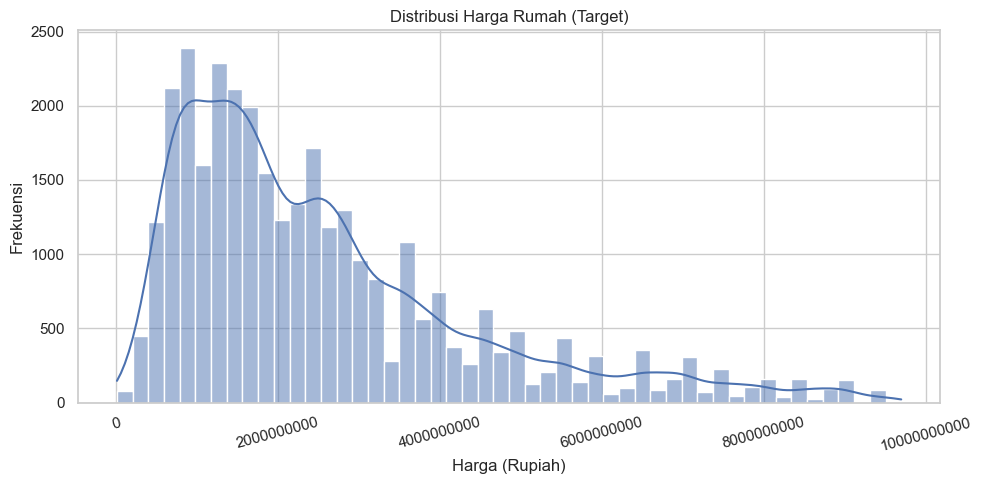

In [815]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], kde=True, bins=50)
plt.title('Distribusi Harga Rumah (Target)')
plt.xlabel('Harga (Rupiah)')
plt.ylabel('Frekuensi')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

right skewed, log1p for preprocessing

3. Exploratory Data Analysis (EDA)

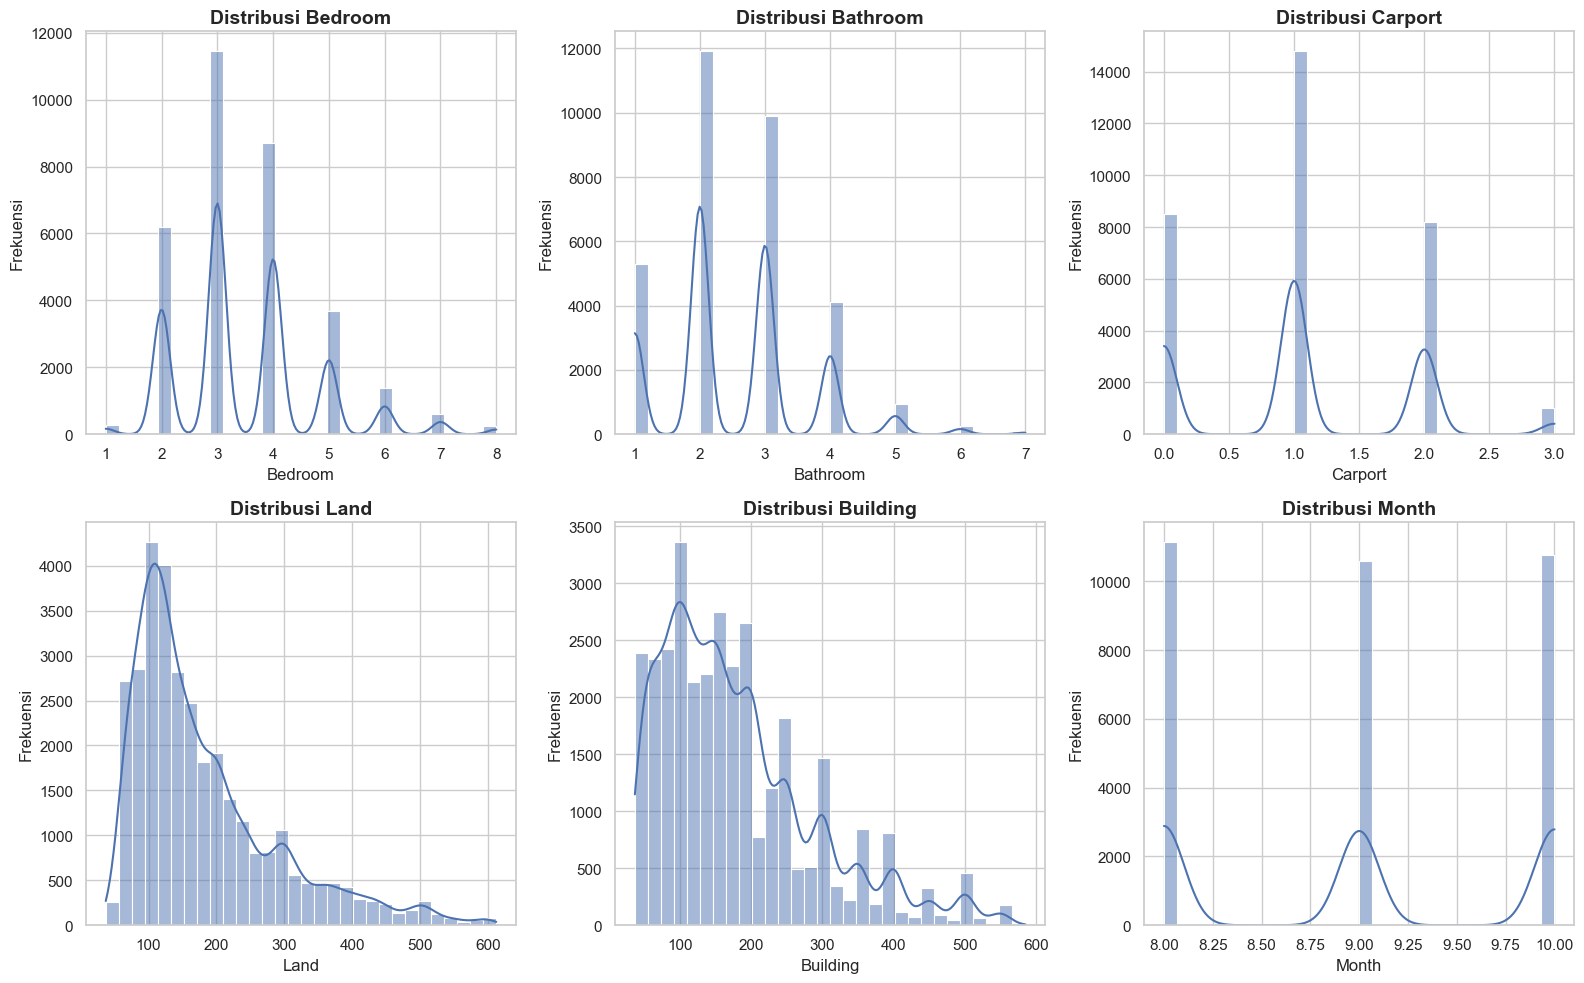

In [816]:
kolom_numerik = ['Bedroom', 'Bathroom', 'Carport', 'Land', 'Building', 'Month']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

right skewed for building & land, log1p

In [817]:
cek_kolom_outlier = ['Land', 'Building']
outlier_report = {}

for col in cek_kolom_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = outliers.sum()
    print(f"{col}: {outliers.sum()} outlier ({outliers.mean()*100:.2f}%)")

Land: 1729 outlier (5.31%)
Building: 1174 outlier (3.61%)


ignore outliers, bcs it make sense

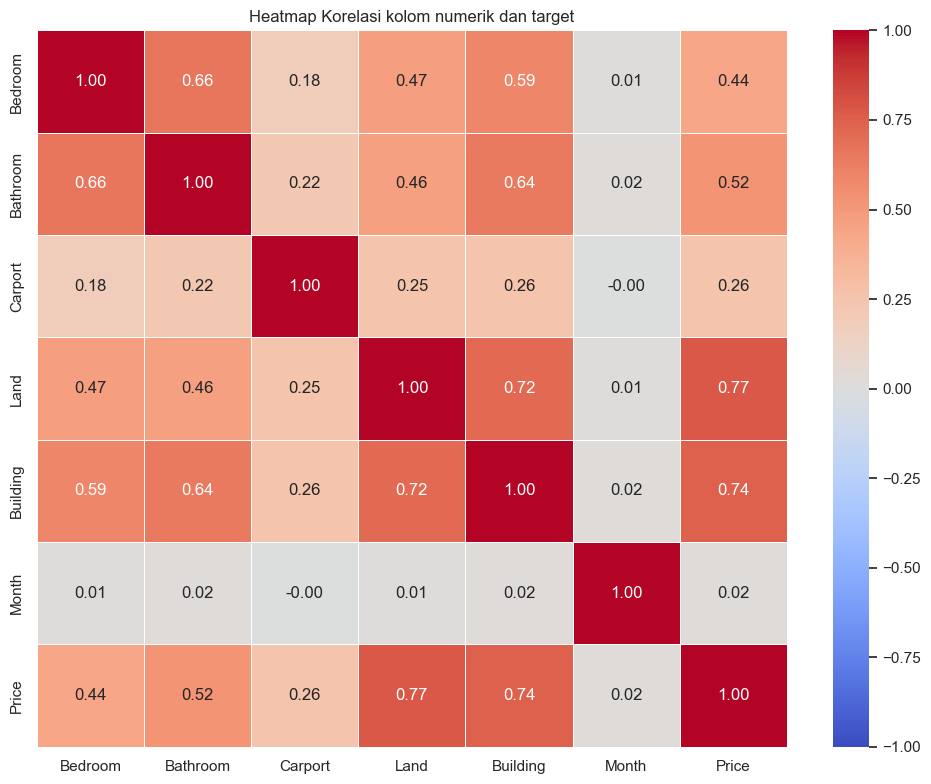

In [818]:
kolom_numerik = ['Bedroom', 'Bathroom', 'Carport', 'Land', 'Building', 'Month', 'Price']
corr_matrix = df[kolom_numerik].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Heatmap Korelasi kolom numerik dan target')
plt.tight_layout()
plt.show()

In [819]:
x = df[kolom_numerik]
x_with_const = add_constant(x)

vif_df = pd.DataFrame()
vif_df['Fitur'] = x_with_const.columns
vif_df['VIF'] = [variance_inflation_factor(x_with_const.values, i) for i in range(len(x_with_const.columns))]

vif_df = vif_df[vif_df["Fitur"] != "const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_df)

      Fitur  VIF
0  Building    3
1     Price    3
2      Land    3
3  Bathroom    2
4   Bedroom    2
5   Carport    1
6     Month    1


drop kolom month

In [820]:
target = 'Price'

categorical_cols = [
    'Location',
    'City/Regency'
]
for col in categorical_cols:
    kategori_groups = [group[target].dropna() for _, group in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*kategori_groups)
    print(f_stat)
    print(p_val)

234.2626280653126
0.0
1281.9955808095938
0.0


these two feature is relevant for the target

4. Data Preprocessing

In [821]:
X = df.drop(columns=['Price', 'Month'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 


5. Feature Engineering

In [822]:
def engineer_features(df):
    X = df.copy()
    X["Total_Rooms"] = X["Bedroom"] + X["Bathroom"]
    X["Bath_per_Bed_Ratio"] = X["Bathroom"] / (X["Bedroom"] + 1e-6)
    X["Building_per_Bedroom"] = X["Building"] / (X["Bedroom"] + 1e-6)
    X["Land_Sisa"] = np.maximum(0, X["Land"] - X["Building"])
    return X

feature_engineer_step = FunctionTransformer(engineer_features)

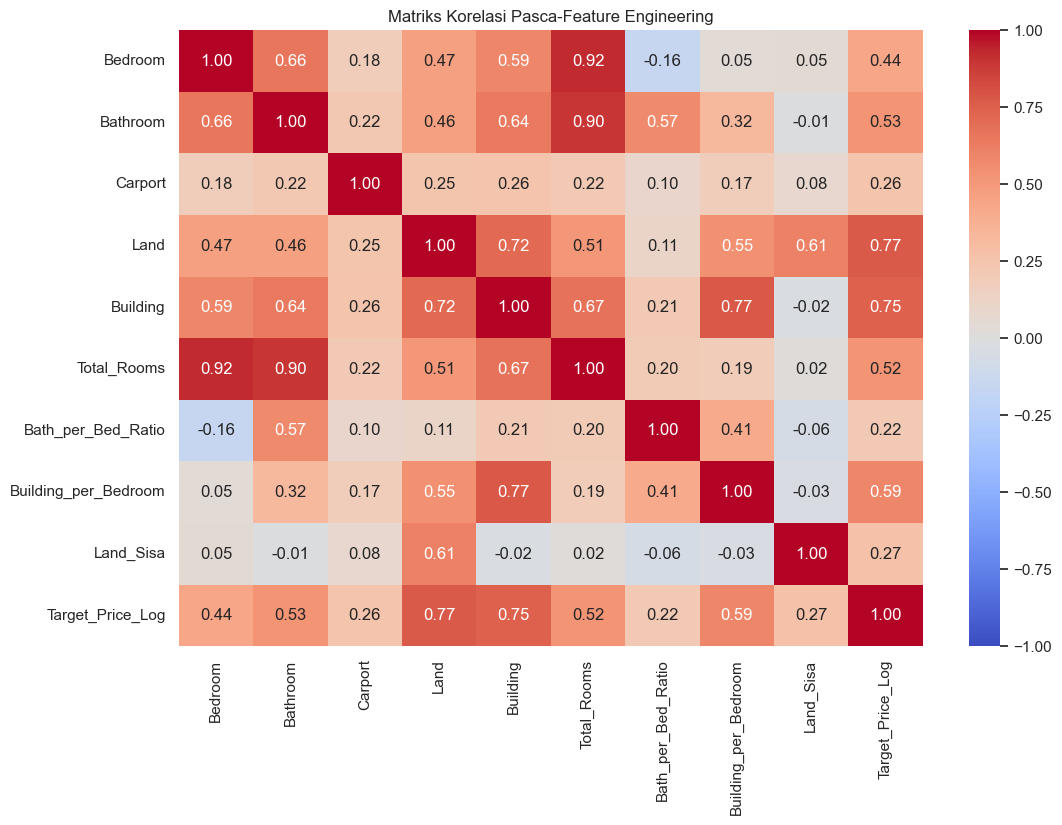

In [823]:
X_train_fe = engineer_features(X_train)

train_check = X_train_fe.copy()
train_check['Target_Price_Log'] = y_train

corr_matrix = train_check.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriks Korelasi Pasca-Feature Engineering')
plt.show()

In [824]:
preprocessor = ColumnTransformer(
    transformers=[
        ('log1p', FunctionTransformer(np.log1p), ['Land', 'Building', 'Bath_per_Bed_Ratio', 'Building_per_Bedroom']),
        ('cat', OneHotEncoder(), ['City/Regency']),
        ('scale', StandardScaler(), ['Bedroom', 'Bathroom', 'Carport', 'Total_Rooms', 'Land_Sisa']),
        ('target_enc', TargetEncoder(smooth="auto", cv=5), ['Location'])
    ],
    remainder='passthrough'
)

In [825]:
full_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer_step),
        ("preprocessor", preprocessor),
    ]
)

In [826]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
X_train_transformed = full_pipeline.fit_transform(X_train, y_train_log)
X_test_transformed = full_pipeline.transform(X_test)

6. Modeling

In [827]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:absoluteerror", eval_metric="mae", random_state=42),
    "LightGBM": LGBMRegressor(objective="regression_l1", metric="mae", random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(loss_function="MAE", eval_metric="MAE", random_seed=42, verbose=0),
}

In [828]:
def build_pipeline(model):
    return Pipeline(steps=[
        ("feature_engineering", feature_engineer_step),
        ("preprocessor", preprocessor),
        ("model", model),
    ])


In [829]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}
 
results = []
for name, model in models.items():
    start = time.time()
    pipe = build_pipeline(model)
 
    cv_results = cross_validate(
        pipe, X_train, y_train_log,
        cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=False
    )
    elapsed = time.time() - start
 
    results.append({
        "Model": name,
        "RMSE (log)": -cv_results["test_RMSE"].mean(),
        "RMSE std": cv_results["test_RMSE"].std(),
        "MAE (log)": -cv_results["test_MAE"].mean(),
        "R2": cv_results["test_R2"].mean(),
        "Waktu (s)": elapsed,
    })
    print(f"{name:<25} selesai ({elapsed:.1f}s)")
 
results_df = pd.DataFrame(results).sort_values("RMSE (log)").reset_index(drop=True)
print("\n=== Perbandingan Model (skala log) ===")
print(results_df)

Linear Regression         selesai (0.1s)
Ridge Regression          selesai (0.1s)
Lasso Regression          selesai (0.1s)
ElasticNet                selesai (0.1s)
KNN Regressor             selesai (0.2s)
Decision Tree             selesai (0.2s)
Random Forest             selesai (4.3s)
Extra Trees               selesai (3.0s)
Gradient Boosting         selesai (2.4s)
HistGradientBoosting      selesai (0.6s)
XGBoost                   selesai (0.8s)
LightGBM                  selesai (2.7s)
CatBoost                  selesai (7.9s)

=== Perbandingan Model (skala log) ===
                   Model  RMSE (log)  RMSE std  MAE (log)  R2  Waktu (s)
0            Extra Trees           0         0          0   1          3
1          Random Forest           0         0          0   1          4
2                XGBoost           0         0          0   1          1
3   HistGradientBoosting           0         0          0   1          1
4               CatBoost           0         0          0   1 

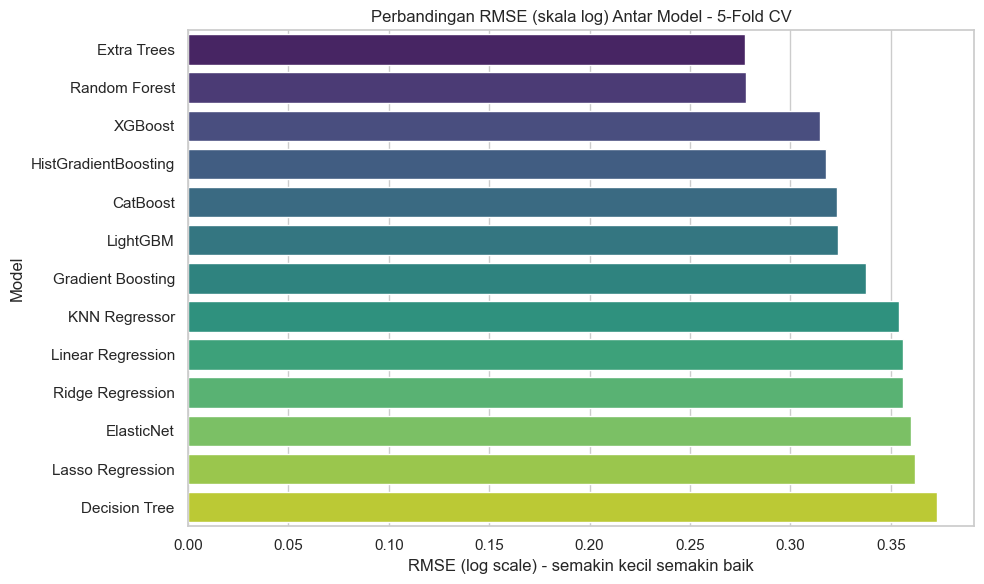

In [830]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="RMSE (log)", y="Model", palette="viridis")
plt.title("Perbandingan RMSE (skala log) Antar Model - 5-Fold CV")
plt.xlabel("RMSE (log scale) - semakin kecil semakin baik")
plt.tight_layout()
plt.show()

In [831]:
top_n = 5
top_models = results_df.head(top_n)["Model"].tolist()
 
original_scale_results = []
for name in top_models:
    pipe = build_pipeline(models[name])
    y_pred_log = cross_val_predict(pipe, X_train, y_train_log, cv=cv, n_jobs=-1)
 
    y_true_asli = np.expm1(y_train_log)
    y_pred_asli = np.expm1(y_pred_log)
 
    original_scale_results.append({
        "Model": name,
        "RMSE (Rupiah)": root_mean_squared_error(y_true_asli, y_pred_asli),
        "MAE (Rupiah)": mean_absolute_error(y_true_asli, y_pred_asli),
        "R2": r2_score(y_true_asli, y_pred_asli),
        "MAPE (%)": mean_absolute_percentage_error(y_true_asli, y_pred_asli) * 100,
    })
 
original_scale_df = pd.DataFrame(original_scale_results).sort_values("RMSE (Rupiah)").reset_index(drop=True)
pd.options.display.float_format = "{:,.0f}".format
print("\n=== Perbandingan Top Model (skala asli / Rupiah) ===")
print(original_scale_df)


=== Perbandingan Top Model (skala asli / Rupiah) ===
                  Model  RMSE (Rupiah)  MAE (Rupiah)  R2  MAPE (%)
0           Extra Trees    667,929,304   353,794,326   1        24
1         Random Forest    682,587,777   385,115,088   1        25
2               XGBoost    800,493,750   496,103,240   1        31
3              CatBoost    827,585,129   526,897,979   1        32
4  HistGradientBoosting    834,347,589   540,327,771   1        31


In [ ]:
best_model_name = original_scale_df.iloc[0]["Model"]
print(f"\nModel terbaik sementara: {best_model_name}")
best_pipeline = build_pipeline(models[best_model_name])


Model terbaik sementara: Extra Trees


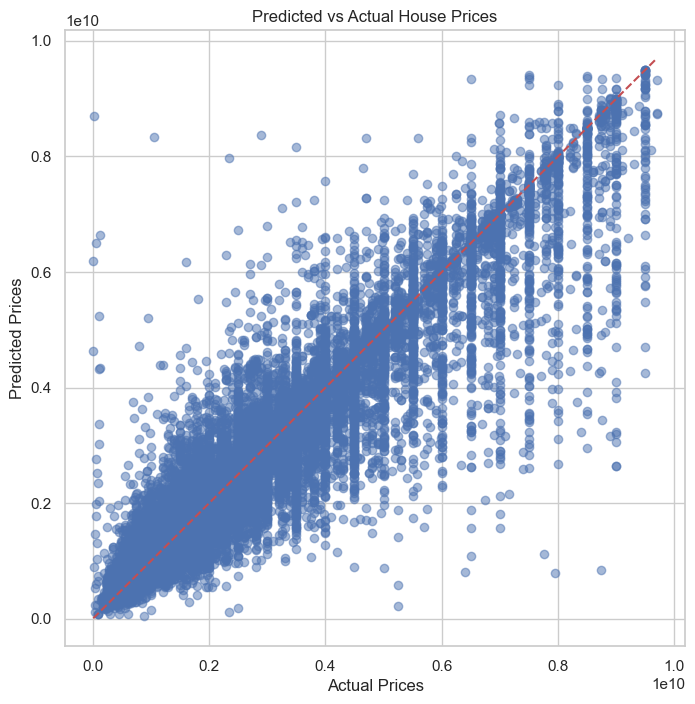

In [835]:
def plot_pred_actual(y_true, y_pred):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title('Predicted vs Actual House Prices')
    plt.show()

best_pipeline = build_pipeline(models[best_model_name])
y_pred_log_best = cross_val_predict(best_pipeline, X_train, y_train_log, cv=cv, n_jobs=-1)

y_true_asli = np.expm1(y_train_log)
y_pred_asli_best = np.expm1(y_pred_log_best)

plot_pred_actual(y_true_asli, y_pred_asli_best)